# Diagnóstico de fragmentación de tracking

Detecta **dónde, cuándo y por qué** se fragmentan las trayectorias.

## Requisitos
- **`data/tracking_match.csv`** — CSV completo del partido (generado por el pipeline). Si no está disponible, el notebook carga automáticamente el CSV de ejemplo incluido en `data/example_banyoles/tracking_sample.csv` (segmento de 30 s, suficiente para las secciones de diagnóstico básico).
- Para el **visor interactivo** (sección 11) se necesitan adicionalmente `left.mp4` y `right.mp4` en el directorio raíz.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter
import os
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#060d1a'
plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': '#0c1830',
    'text.color': 'white', 'axes.labelcolor': '#8a9bbf',
    'xtick.color': '#8a9bbf', 'ytick.color': '#8a9bbf',
    'axes.edgecolor': '#1a3060', 'grid.color': '#1a3060',
    'legend.facecolor': '#0c1830', 'legend.edgecolor': '#333',
})

# ── CONFIG ───────────────────────────────────────────────────────────────────
_FULL_CSV   = 'data/tracking_match.csv'
_SAMPLE_CSV = 'data/example_banyoles/tracking_sample.csv'
CSV_PATH    = _FULL_CSV if os.path.exists(_FULL_CSV) else _SAMPLE_CSV
FPS         = 29.97
L_M, A_M   = 98.0, 61.0   # dimensiones del campo en metros
SEAM_X      = 53.5          # posición X de la costura bicámara

COLOR = {
    'player_home': '#dc143c', 'player_away': '#1e90ff',
    'gk_home':     '#ff00ff', 'gk_away':    '#00ced1',
    'referee':     '#f0c040', 'unknown':    '#888888',
}
TEAM_HOME = {'player_home', 'gk_home'}
TEAM_AWAY = {'player_away', 'gk_away'}

# ── CARGA ────────────────────────────────────────────────────────────────────
print(f'Cargando: {CSV_PATH}')
df = pd.read_csv(CSV_PATH)

if 'track_id' in df.columns and 'gid' not in df.columns:
    df = df.rename(columns={'track_id': 'gid', 'class': 'cls', 'x': 'x_m', 'y': 'y_m', 't': 'time_s'})

if 'time_s' not in df.columns:
    df['time_s'] = (df['frame'] - df['frame'].min()) / FPS

df = df.sort_values(['gid', 'frame']).reset_index(drop=True)
t_offset = df['frame'].min()
df['t_min'] = (df['frame'] - t_offset) / FPS / 60

print(f"Frames: {df['frame'].min()} – {df['frame'].max()}  "
      f"({df['t_min'].max():.1f} min)")
print(f"Detecciones totales : {len(df):,}")
print(f"IDs únicos          : {df['gid'].nunique()}")
print(f"Frames únicos       : {df['frame'].nunique()}")
print(f"Det/frame media     : {len(df)/df['frame'].nunique():.1f}")
print()
print(df['cls'].value_counts().to_string())

## 1  Resumen de fragmentación por clase

In [58]:
# Duración de cada track en frames y segundos
track_info = (df.groupby('gid')
                .agg(cls=('cls', lambda x: x.mode()[0]),
                     f_start=('frame', 'min'),
                     f_end=('frame', 'max'),
                     n_frames=('frame', 'count'),
                     mean_x=('x_m', 'mean'),
                     mean_y=('y_m', 'mean'),
                     mean_conf=('conf', 'mean') if 'conf' in df.columns else ('x_m', 'count'))
                .reset_index())
track_info['duration_s'] = (track_info['f_end'] - track_info['f_start'] + 1) / FPS
track_info['t_start_min'] = (track_info['f_start'] - t_offset) / FPS / 60

# Tabla por clase
EXPECTED = {'player_home': 11, 'player_away': 11, 'gk_home': 1, 'gk_away': 1, 'referee': 1}
print(f"{'Clase':<14} {'IDs':>5}  {'Esperado':>8}  {'Ratio':>6}  "
      f"{'Dur_median_s':>12}  {'Dur_mean_s':>10}  {'<2s %':>6}")
print('─' * 68)
for cls in ['player_home', 'player_away', 'gk_home', 'gk_away', 'referee', 'unknown']:
    sub = track_info[track_info['cls'] == cls]
    if not len(sub): continue
    exp = EXPECTED.get(cls, '?')
    ratio = f"{len(sub)/exp:.0f}x" if isinstance(exp, int) else '?'
    pct_short = (sub['duration_s'] < 2).mean() * 100
    print(f"{cls:<14} {len(sub):>5}  {str(exp):>8}  {ratio:>6}  "
          f"{sub['duration_s'].median():>12.1f}  {sub['duration_s'].mean():>10.1f}  "
          f"{pct_short:>5.0f}%")

Clase            IDs  Esperado   Ratio  Dur_median_s  Dur_mean_s   <2s %
────────────────────────────────────────────────────────────────────
player_home      414        11     38x          37.3        64.9      6%
player_away      391        11     36x          39.2        61.4      6%
gk_home           35         1     35x          29.0        77.6      9%
gk_away           11         1     11x         154.8       264.7      0%
referee          142         1    142x          18.6        32.9      8%
unknown            9         ?       ?           1.7         3.2     56%


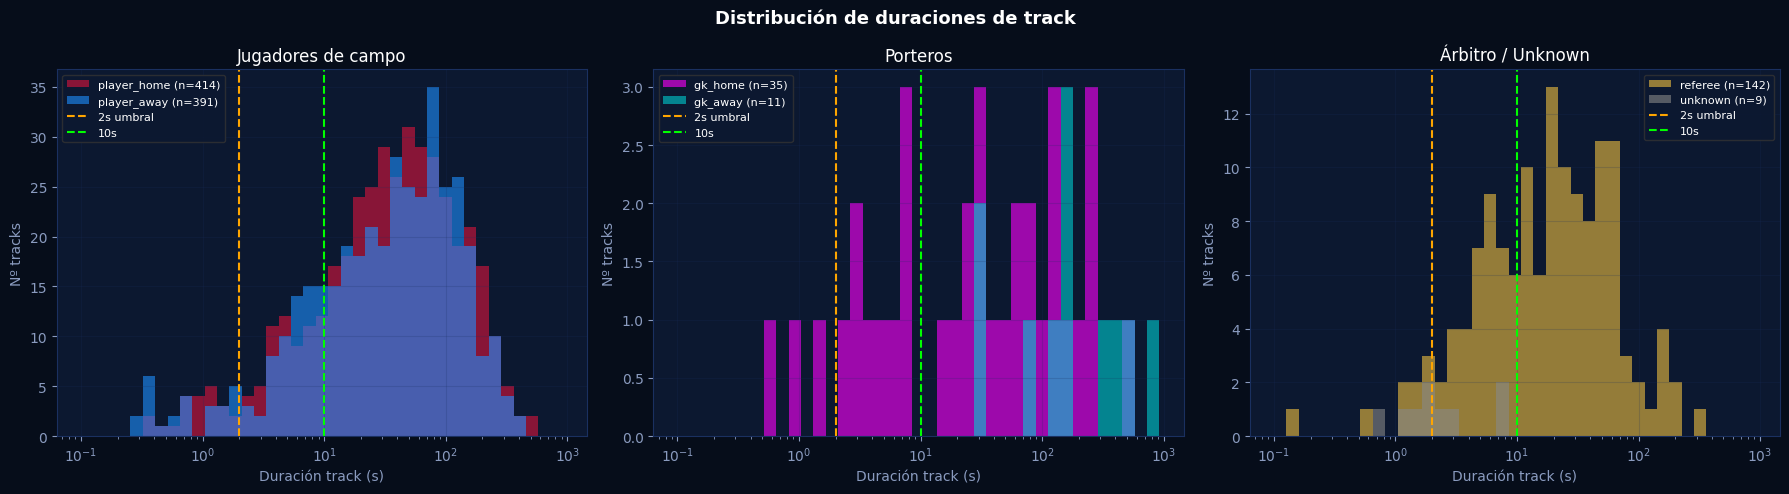

In [59]:
# Distribución de duraciones — histograma + percentiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bins = np.logspace(np.log10(0.1), np.log10(track_info['duration_s'].max() + 1), 40)

for ax, cls_group, title in [
    (axes[0], ['player_home', 'player_away'], 'Jugadores de campo'),
    (axes[1], ['gk_home', 'gk_away'],         'Porteros'),
    (axes[2], ['referee', 'unknown'],          'Árbitro / Unknown'),
]:
    for cls in cls_group:
        sub = track_info[track_info['cls'] == cls]['duration_s']
        if not len(sub): continue
        ax.hist(sub, bins=bins, alpha=0.6, label=f'{cls} (n={len(sub)})',
                color=COLOR.get(cls, '#aaa'))
    ax.axvline(2,  color='orange', lw=1.5, ls='--', label='2s umbral')
    ax.axvline(10, color='lime',   lw=1.5, ls='--', label='10s')
    ax.set_xscale('log')
    ax.set_xlabel('Duración track (s)')
    ax.set_ylabel('Nº tracks')
    ax.set_title(title, color='white')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle('Distribución de duraciones de track', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_duraciones.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 2  Timeline de fragmentación — nacimientos de IDs por ventana temporal

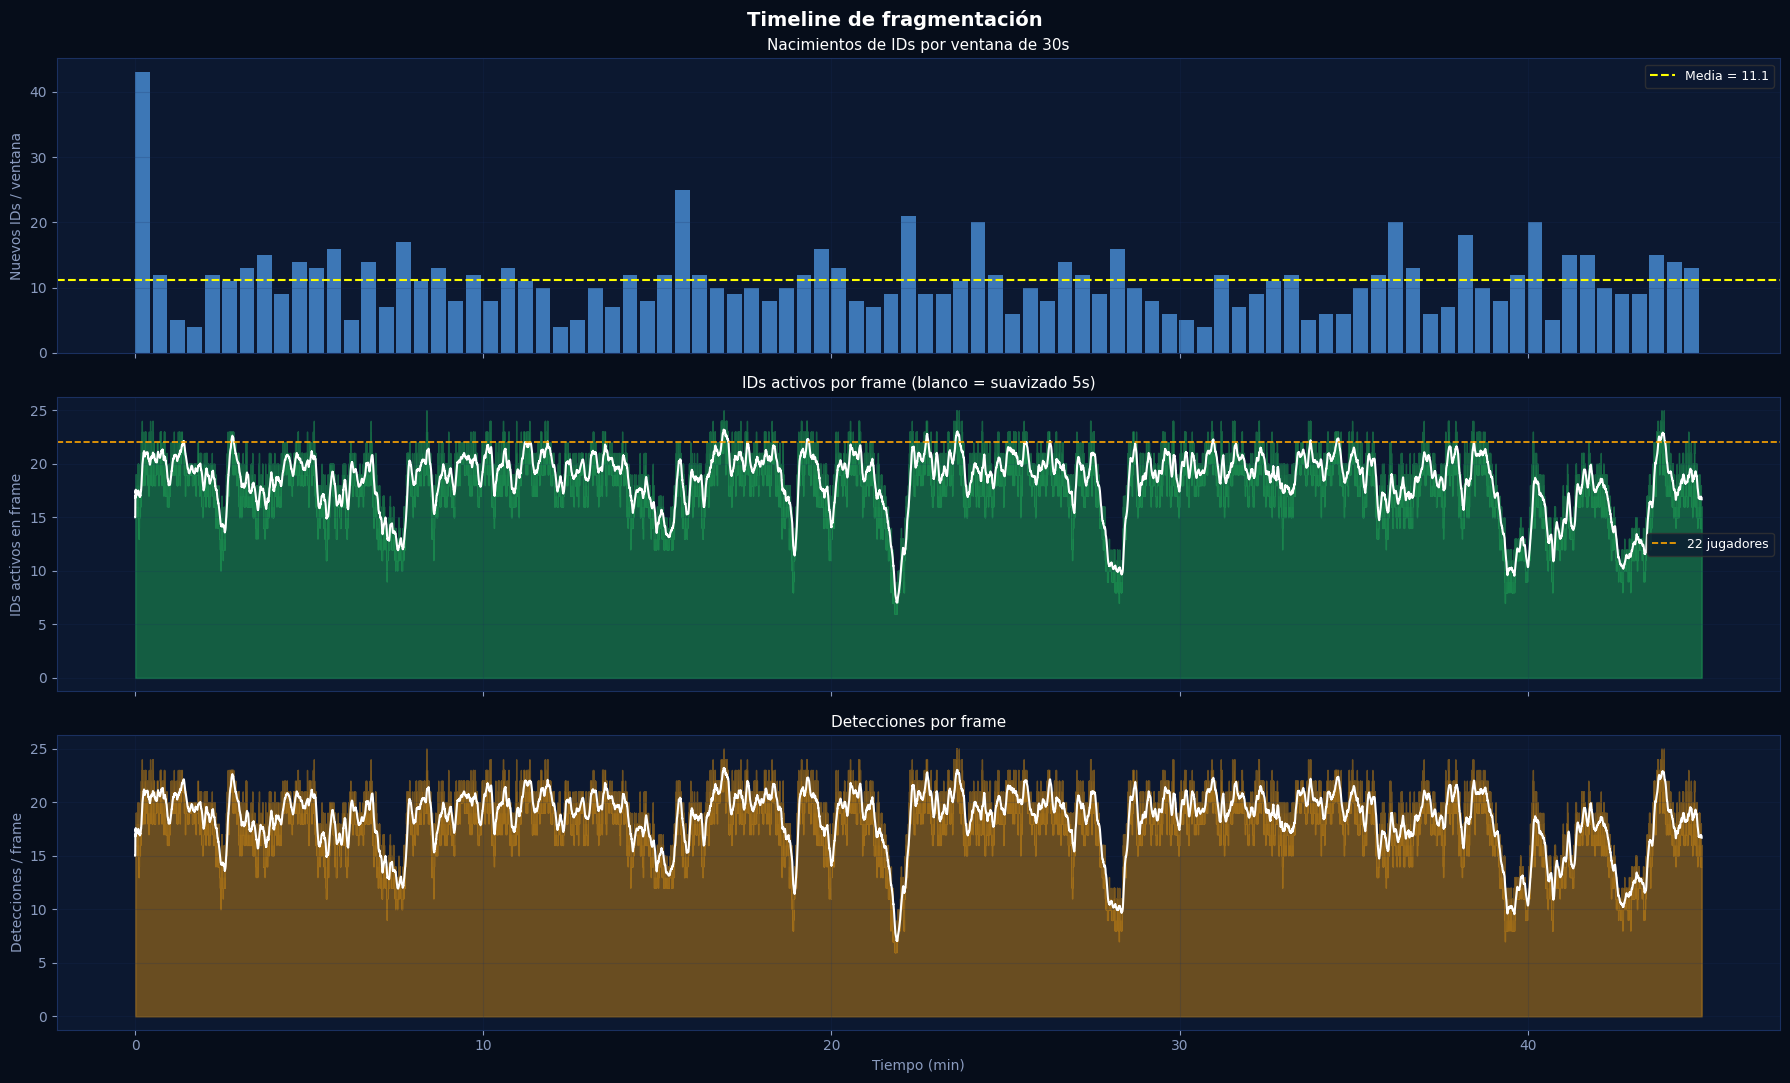

Top 5 ventanas con más nacimientos de IDs:
  t=0.0–0.5 min → 43 IDs nuevos
  t=15.5–16.0 min → 25 IDs nuevos
  t=22.0–22.5 min → 21 IDs nuevos
  t=24.0–24.5 min → 20 IDs nuevos
  t=36.0–36.5 min → 20 IDs nuevos


In [60]:
WINDOW_S = 30  # ventana en segundos
window_f = int(WINDOW_S * FPS)

f_min, f_max = df['frame'].min(), df['frame'].max()
edges = np.arange(f_min, f_max + window_f, window_f)
bins_t = (edges - f_min) / FPS / 60

# Nuevos IDs por clase por ventana
births = track_info.copy()
births['bin'] = pd.cut(births['f_start'], bins=edges, labels=False, right=False)

fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

# Panel 1: nuevos IDs totales
ax0 = axes[0]
total_by_bin = births.groupby('bin').size()
x_vals = [bins_t[int(b)] if not pd.isna(b) else 0 for b in total_by_bin.index]
ax0.bar(x_vals, total_by_bin.values, width=WINDOW_S/60*0.85,
        color='#4a90d9', alpha=0.8, align='edge')
ax0.set_ylabel('Nuevos IDs / ventana')
ax0.set_title(f'Nacimientos de IDs por ventana de {WINDOW_S}s', color='white', fontsize=11)
ax0.axhline(total_by_bin.mean(), color='yellow', lw=1.5, ls='--',
            label=f'Media = {total_by_bin.mean():.1f}')
ax0.legend(fontsize=9); ax0.grid(alpha=0.2)

# Panel 2: IDs activos por frame
ax1 = axes[1]
ids_per_frame = df.groupby('frame')['gid'].nunique()
t_frames = (ids_per_frame.index - f_min) / FPS / 60
ax1.fill_between(t_frames, ids_per_frame.values, alpha=0.4, color='#22c55e')
ax1.plot(t_frames, ids_per_frame.rolling(int(FPS*5), min_periods=1).mean().values,
         color='white', lw=1.5)
ax1.axhline(22, color='orange', lw=1.2, ls='--', label='22 jugadores')
ax1.set_ylabel('IDs activos en frame')
ax1.set_title('IDs activos por frame (blanco = suavizado 5s)', color='white', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(alpha=0.2)

# Panel 3: detecciones por frame (proxy del detector)
ax2 = axes[2]
dets_per_frame = df.groupby('frame').size()
ax2.fill_between((dets_per_frame.index - f_min)/FPS/60,
                  dets_per_frame.values, alpha=0.4, color='#f59e0b')
ax2.plot((dets_per_frame.index - f_min)/FPS/60,
          dets_per_frame.rolling(int(FPS*5), min_periods=1).mean().values,
          color='white', lw=1.5)
ax2.set_ylabel('Detecciones / frame')
ax2.set_xlabel('Tiempo (min)')
ax2.set_title('Detecciones por frame', color='white', fontsize=11)
ax2.grid(alpha=0.2)

fig.suptitle('Timeline de fragmentación', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_timeline.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

# Ventanas con más fragmentación
top5 = births.groupby('bin').size().nlargest(5)
print("Top 5 ventanas con más nacimientos de IDs:")
for b, n in top5.items():
    t = bins_t[int(b)]
    print(f"  t={t:.1f}–{t+WINDOW_S/60:.1f} min → {n} IDs nuevos")

## 3  Análisis espacial — ¿dónde nacen los tracks?

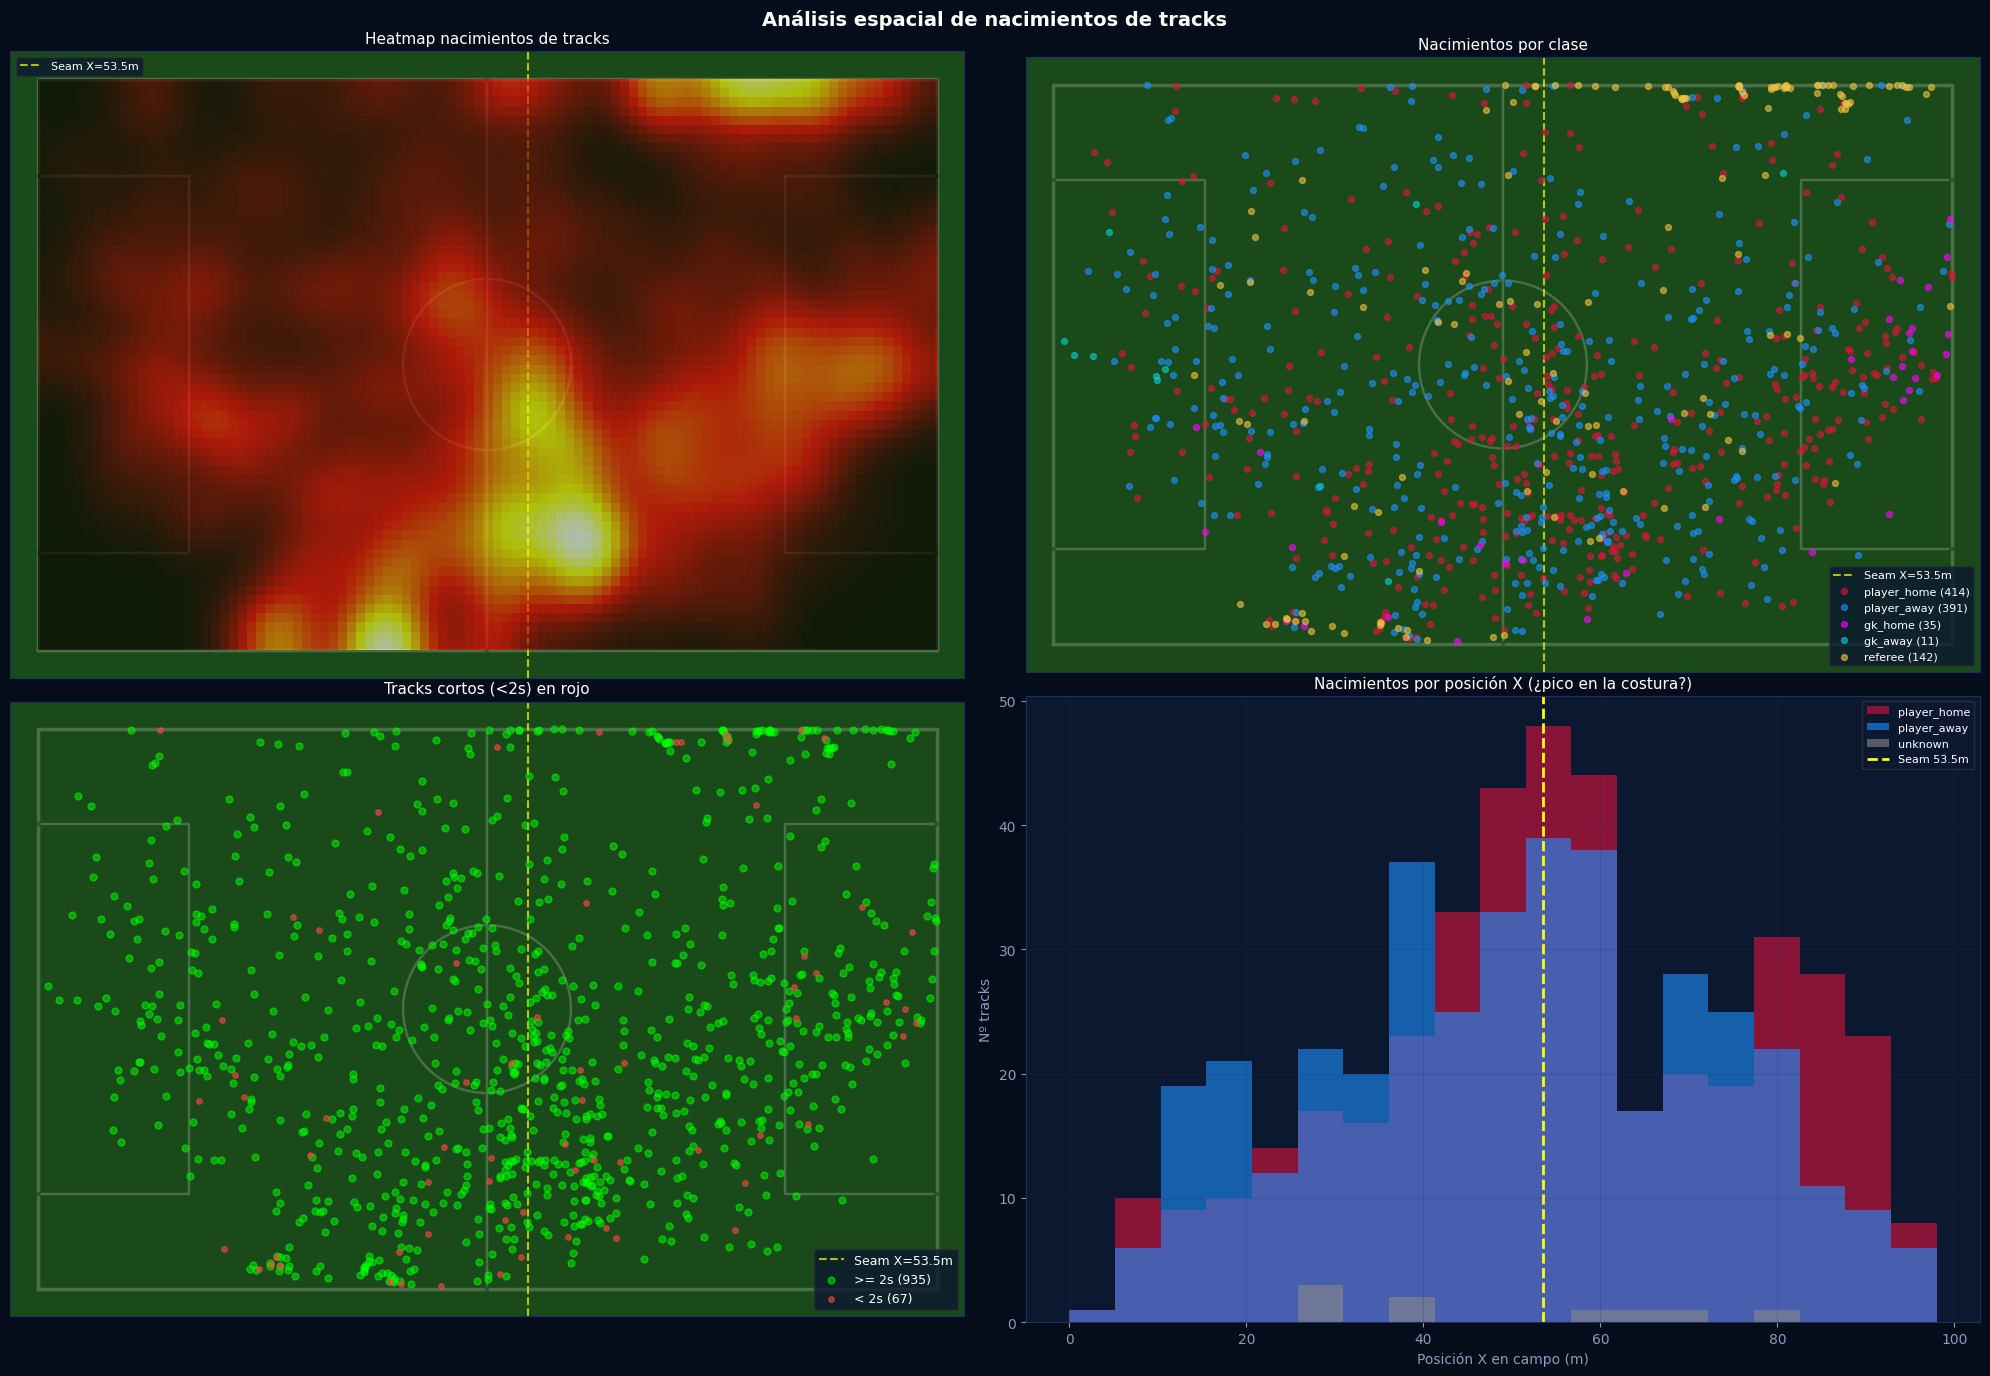

Tracks nacidos en zona ±10m de la costura: 330 / 1002 = 32.9%
(si >35% la costura es el problema principal)


In [61]:
def draw_pitch(ax, alpha=0.7):
    ax.set_facecolor('#1a4a1a')
    ax.set_xlim(-3, L_M + 3); ax.set_ylim(-3, A_M + 3)
    for lw, col in [(2.5, 'white'), (4, '#1a4a1a')]:
        ax.plot([0,L_M,L_M,0,0], [0,0,A_M,A_M,0], color=col, lw=lw, alpha=alpha)
        ax.plot([L_M/2,L_M/2], [0,A_M], color=col, lw=lw*0.7, alpha=alpha)
        circ = plt.Circle((L_M/2, A_M/2), 9.15, color=col, fill=False, lw=lw*0.7, alpha=alpha)
        ax.add_patch(circ)
        for gx in [0, L_M]:
            ax.plot([gx, gx + (16.5 if gx==0 else -16.5), gx + (16.5 if gx==0 else -16.5), gx],
                    [(A_M-40.32)/2, (A_M-40.32)/2, (A_M+40.32)/2, (A_M+40.32)/2],
                    color=col, lw=lw*0.7, alpha=alpha)
    ax.axvline(SEAM_X, color='yellow', lw=1.5, ls='--', alpha=0.7, label=f'Seam X={SEAM_X}m')
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

births_xy = track_info[['gid','cls','mean_x','mean_y','duration_s','f_start']].copy()
births_xy = births_xy.merge(
    df.groupby('gid').first()[['x_m','y_m']].rename(columns={'x_m':'birth_x','y_m':'birth_y'}),
    left_on='gid', right_index=True, how='left'
)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor(DARK_BG)

# Heatmap de nacimientos
ax = axes[0,0]
draw_pitch(ax)
hm = np.zeros((int(A_M)+1, int(L_M)+1))
for _, r in births_xy.dropna(subset=['birth_x','birth_y']).iterrows():
    xi, yi = int(np.clip(r['birth_x'], 0, L_M-1)), int(np.clip(r['birth_y'], 0, A_M-1))
    hm[yi, xi] += 1
hm_s = gaussian_filter(hm, sigma=3)
ax.imshow(hm_s, extent=[0,L_M,A_M,0], origin='upper', cmap='hot', alpha=0.65,
          vmin=0, aspect='auto', zorder=4)
ax.set_title('Heatmap nacimientos de tracks', color='white', fontsize=11)
ax.legend(fontsize=8, loc='upper left')

# Scatter por clase
ax = axes[0,1]
draw_pitch(ax)
for cls in ['player_home','player_away','gk_home','gk_away','referee']:
    sub = births_xy[births_xy['cls']==cls].dropna(subset=['birth_x','birth_y'])
    if not len(sub): continue
    ax.scatter(sub['birth_x'], sub['birth_y'], s=18, alpha=0.6,
               color=COLOR[cls], label=f'{cls} ({len(sub)})', zorder=5)
ax.set_title('Nacimientos por clase', color='white', fontsize=11)
ax.legend(fontsize=8)

# Tracks cortos (< 2s) vs largos
ax = axes[1,0]
draw_pitch(ax)
short = births_xy[births_xy['duration_s'] < 2].dropna(subset=['birth_x','birth_y'])
long_ = births_xy[births_xy['duration_s'] >= 2].dropna(subset=['birth_x','birth_y'])
ax.scatter(long_['birth_x'], long_['birth_y'],  s=25, alpha=0.5, color='lime',   label=f'>= 2s ({len(long_)})', zorder=5)
ax.scatter(short['birth_x'], short['birth_y'], s=15, alpha=0.6, color='#ff4444', label=f'< 2s ({len(short)})',  zorder=6)
ax.set_title('Tracks cortos (<2s) en rojo', color='white', fontsize=11)
ax.legend(fontsize=9)

# Distribución por franja X del campo
ax = axes[1,1]
ax.set_facecolor('#0c1830')
bins_x = np.linspace(0, L_M, 20)
for cls in ['player_home','player_away','unknown']:
    sub = births_xy[births_xy['cls']==cls]['birth_x'].dropna()
    if not len(sub): continue
    ax.hist(sub, bins=bins_x, alpha=0.6, label=cls, color=COLOR.get(cls,'#aaa'))
ax.axvline(SEAM_X, color='yellow', lw=2, ls='--', label=f'Seam {SEAM_X}m')
ax.set_xlabel('Posición X en campo (m)')
ax.set_ylabel('Nº tracks')
ax.set_title('Nacimientos por posición X (¿pico en la costura?)', color='white', fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.2)

fig.suptitle('Análisis espacial de nacimientos de tracks', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_espacial.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

seam_margin = 10
near_seam = births_xy[(births_xy['birth_x'] > SEAM_X - seam_margin) &
                       (births_xy['birth_x'] < SEAM_X + seam_margin)]
pct_seam = len(near_seam) / len(births_xy) * 100
print(f"Tracks nacidos en zona ±{seam_margin}m de la costura: "
      f"{len(near_seam)} / {len(births_xy)} = {pct_seam:.1f}%")
print(f"(si >35% la costura es el problema principal)")

## 4  Gap analysis — ¿el skip_frames rompe el tracker?

In [62]:
# Detectar skip_frames efectivo
frames_sorted = sorted(df['frame'].unique())
gaps = np.diff(frames_sorted)
skip_eff = int(np.percentile(gaps, 50))
print(f"Gap mediano entre frames procesados: {skip_eff} frames")
print(f"  → skip_frames efectivo ≈ {skip_eff} ({skip_eff/FPS*1000:.0f} ms / {skip_eff/FPS:.3f}s por gap)")
print()
print("Distribución de gaps:")
unique_gaps, counts = np.unique(gaps, return_counts=True)
for g, c in sorted(zip(unique_gaps, counts), key=lambda x: -x[1])[:8]:
    print(f"  gap={g:3d} frames ({g/FPS*1000:.0f}ms) → {c} veces ({c/len(gaps)*100:.1f}%)")

# A 20 km/h cuántos metros se mueve un jugador en skip_eff frames
speed_ms = 20 / 3.6
dist_per_skip = speed_ms * skip_eff / FPS
print(f"\nA 20 km/h, un jugador se mueve {dist_per_skip:.2f}m en {skip_eff} frames")
print(f"  → si TRACK_MAX_DIST_M es < {dist_per_skip:.1f}m el tracker pierde el jugador en sprints")

Gap mediano entre frames procesados: 1 frames
  → skip_frames efectivo ≈ 1 (33 ms / 0.033s por gap)

Distribución de gaps:
  gap=  1 frames (33ms) → 80916 veces (100.0%)

A 20 km/h, un jugador se mueve 0.19m en 1 frames
  → si TRACK_MAX_DIST_M es < 0.2m el tracker pierde el jugador en sprints


Gaps intra-track totales: 18114
  mediana: 5 frames (0.17s)
  max:     899 frames (30.0s)

Velocidades > 8 m/s (teleports): 8.2% de los pasos


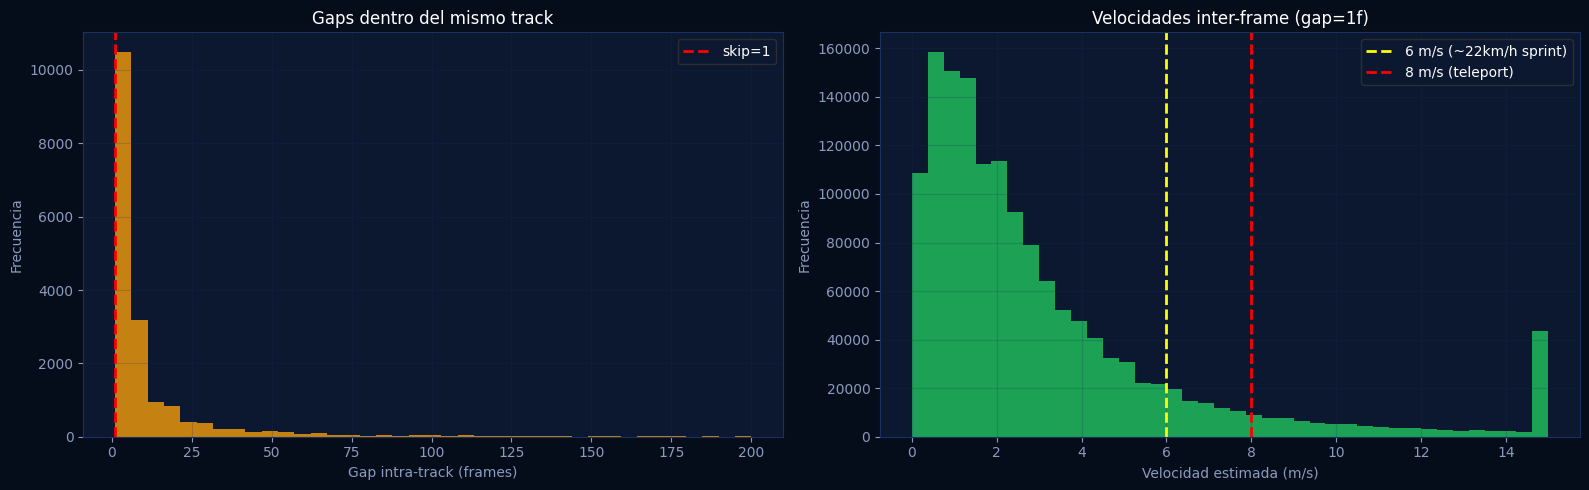

In [63]:
# Gaps DENTRO de cada track (¿cuánto tiempo desaparece un jugador entre detecciones?)
intra_gaps = []
for gid, grp in df.groupby('gid'):
    ff = sorted(grp['frame'].unique())
    for g in np.diff(ff):
        if g > 1:
            intra_gaps.append({'gid': gid, 'gap_f': int(g), 'gap_s': g/FPS})
df_gaps = pd.DataFrame(intra_gaps)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

if len(df_gaps):
    ax = axes[0]
    ax.set_facecolor('#0c1830')
    bins_g = np.linspace(1, min(df_gaps['gap_f'].max(), 200), 40)
    ax.hist(df_gaps['gap_f'], bins=bins_g, color='#f59e0b', alpha=0.8)
    ax.set_xlabel('Gap intra-track (frames)')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Gaps dentro del mismo track', color='white')
    ax.axvline(skip_eff, color='red', lw=2, ls='--', label=f'skip={skip_eff}')
    ax.legend(); ax.grid(alpha=0.2)
    print(f"Gaps intra-track totales: {len(df_gaps)}")
    print(f"  mediana: {df_gaps['gap_f'].median():.0f} frames ({df_gaps['gap_s'].median():.2f}s)")
    print(f"  max:     {df_gaps['gap_f'].max()} frames ({df_gaps['gap_f'].max()/FPS:.1f}s)")

# Distancia de salto inter-frame dentro del track
df_sorted = df.sort_values(['gid','frame'])
df_sorted['dx'] = df_sorted.groupby('gid')['x_m'].diff()
df_sorted['dy'] = df_sorted.groupby('gid')['y_m'].diff()
df_sorted['df_gap'] = df_sorted.groupby('gid')['frame'].diff().fillna(0)
df_sorted['jump_m'] = np.sqrt(df_sorted['dx']**2 + df_sorted['dy']**2)
df_sorted['speed_est'] = df_sorted['jump_m'] / (df_sorted['df_gap'] / FPS).replace(0, np.nan)

ax = axes[1]
ax.set_facecolor('#0c1830')
valid = df_sorted[df_sorted['df_gap'] == skip_eff]['speed_est'].dropna()
if len(valid):
    ax.hist(valid.clip(0, 15), bins=40, color='#22c55e', alpha=0.8)
    ax.axvline(6, color='yellow', lw=2, ls='--', label='6 m/s (~22km/h sprint)')
    ax.axvline(8, color='red',    lw=2, ls='--', label='8 m/s (teleport)')
    ax.set_xlabel('Velocidad estimada (m/s)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Velocidades inter-frame (gap={skip_eff}f)', color='white')
    ax.legend(); ax.grid(alpha=0.2)
    pct_fast = (valid > 8).mean() * 100
    print(f"\nVelocidades > 8 m/s (teleports): {pct_fast:.1f}% de los pasos")

plt.tight_layout()
plt.savefig('diag_gaps.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 5  Diagnóstico del detector — caídas de recall

Frames con < 15 detecciones: 9548 (11.8%)


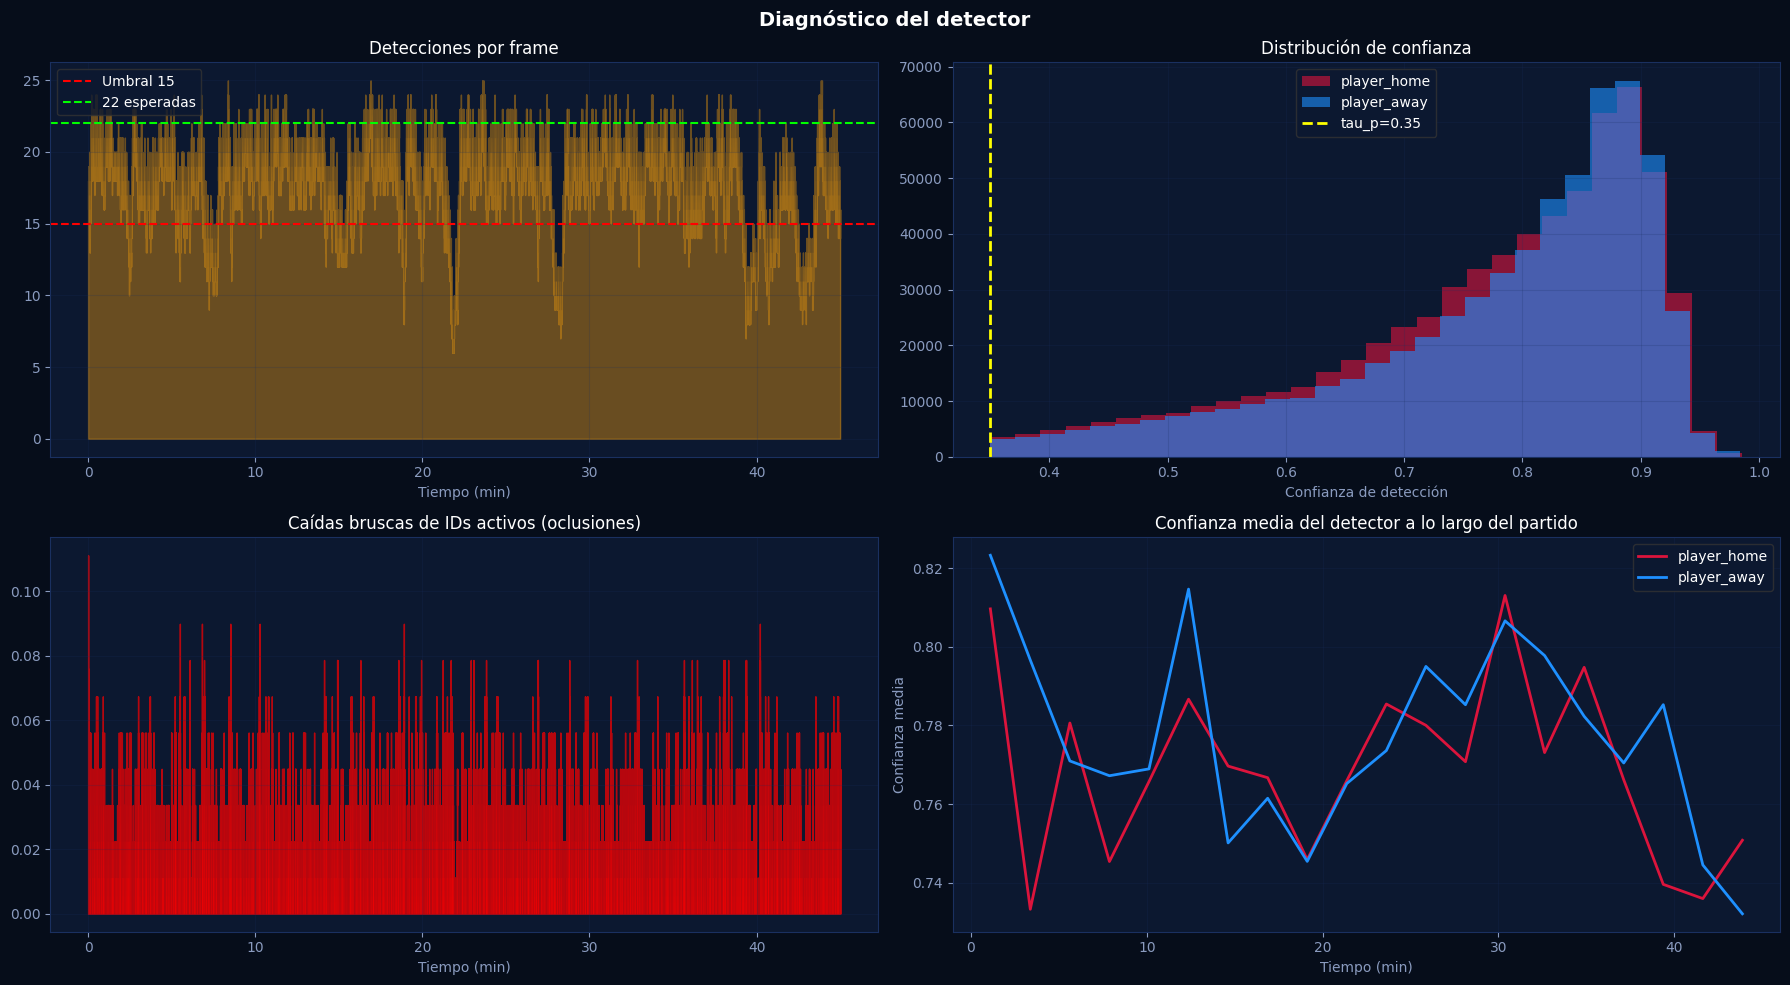

In [64]:
dets_pf = df.groupby('frame').size().reindex(
    range(df['frame'].min(), df['frame'].max()+1), fill_value=0)

LOW_DET_THRESH = 15  # menos de 15 detecciones = posible caída del detector
low_frames = (dets_pf < LOW_DET_THRESH).sum()
print(f"Frames con < {LOW_DET_THRESH} detecciones: {low_frames} "
      f"({low_frames/len(dets_pf)*100:.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor(DARK_BG)

# Detecciones por frame con umbral
ax = axes[0,0]
ax.set_facecolor('#0c1830')
t_all = (dets_pf.index - dets_pf.index.min()) / FPS / 60
ax.fill_between(t_all, dets_pf.values, alpha=0.4, color='#f59e0b')
ax.axhline(LOW_DET_THRESH, color='red', lw=1.5, ls='--', label=f'Umbral {LOW_DET_THRESH}')
ax.axhline(22, color='lime', lw=1.5, ls='--', label='22 esperadas')
ax.set_title('Detecciones por frame', color='white')
ax.set_xlabel('Tiempo (min)'); ax.legend(); ax.grid(alpha=0.2)

# Histograma de confianza
ax = axes[0,1]
ax.set_facecolor('#0c1830')
if 'conf' in df.columns:
    for cls in ['player_home','player_away']:
        sub = df[df['cls']==cls]['conf']
        ax.hist(sub, bins=30, alpha=0.6, label=cls, color=COLOR[cls])
    ax.set_xlabel('Confianza de detección')
    ax.set_title('Distribución de confianza', color='white')
    ax.axvline(0.35, color='yellow', lw=2, ls='--', label='tau_p=0.35')
    ax.legend(); ax.grid(alpha=0.2)

# Missing detections: jugadores que deberían estar pero no están
# Proxy: frames donde active_ids cae bruscamente
ax = axes[1,0]
ax.set_facecolor('#0c1830')
ids_pf = df.groupby('frame')['gid'].nunique()
ids_roll = ids_pf.rolling(int(FPS*3), min_periods=1).mean()
drop = ids_roll.diff().clip(upper=0).abs()
t_ids = (ids_pf.index - ids_pf.index.min()) / FPS / 60
ax.fill_between(t_ids, drop.reindex(ids_pf.index).values, color='red', alpha=0.7)
ax.set_title('Caídas bruscas de IDs activos (oclusiones)', color='white')
ax.set_xlabel('Tiempo (min)'); ax.grid(alpha=0.2)

# Confianza media por clase a lo largo del tiempo
ax = axes[1,1]
ax.set_facecolor('#0c1830')
if 'conf' in df.columns:
    for cls in ['player_home','player_away']:
        sub = df[df['cls']==cls].copy()
        sub['t_min'] = (sub['frame'] - df['frame'].min()) / FPS / 60
        sub_b = sub.groupby(pd.cut(sub['t_min'], bins=20))['conf'].mean()
        centers = [iv.mid for iv in sub_b.index]
        ax.plot(centers, sub_b.values, color=COLOR[cls], lw=2, label=cls)
    ax.set_xlabel('Tiempo (min)')
    ax.set_ylabel('Confianza media')
    ax.set_title('Confianza media del detector a lo largo del partido', color='white')
    ax.legend(); ax.grid(alpha=0.2)

fig.suptitle('Diagnóstico del detector', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_detector.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 6  Oportunidades de Re-ID perdidas

Tracks totales         : 1002
Pares recuperables Re-ID: 435 (43.4%)
  → distancia media    : 4.51m
  → gap medio          : 8.8s

Por clase:
               n  dist_med   gap_med
cls                                 
gk_away        3  2.738266  8.441775
gk_home       13  5.329587  7.173841
player_away  180  4.406136  6.473140
player_home  193  4.895232  5.772439
referee       46  4.673134  4.471138


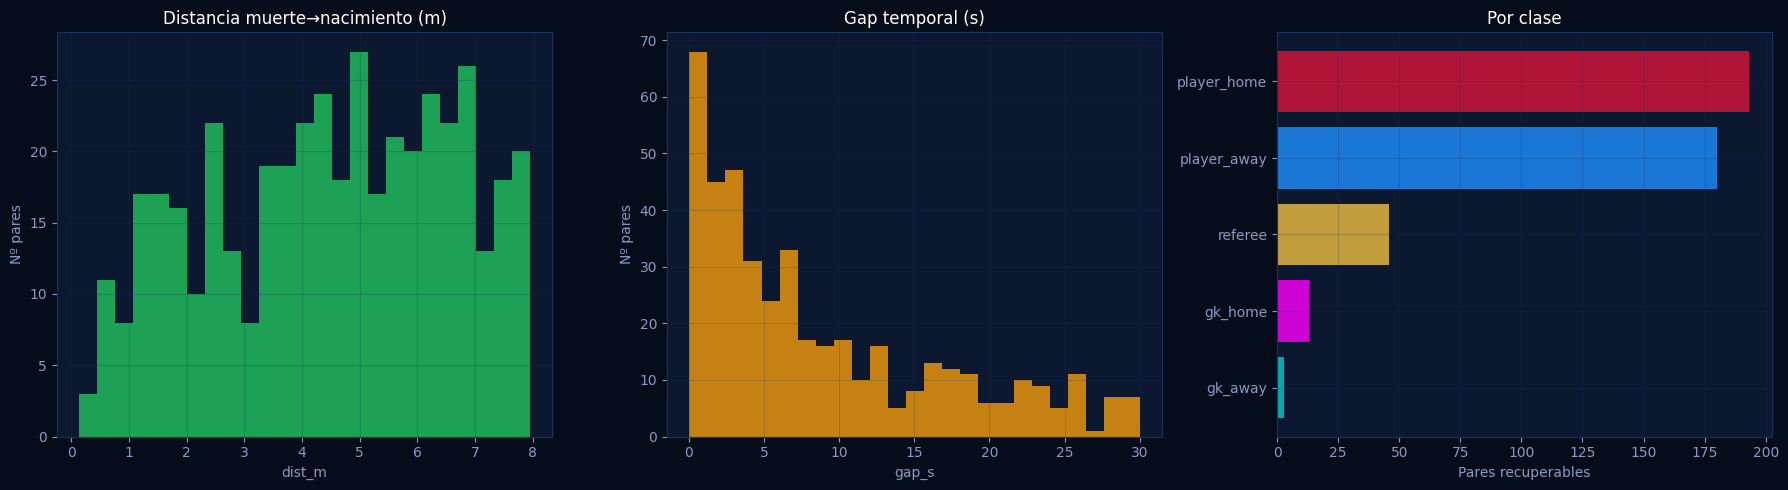

In [65]:
# Para cada track que MUERE, ¿hay otro track de la misma clase que NACE cerca?
# Proxy de cuántos fragmentos podrían conectarse con mejor Re-ID
MAX_DIST_REID   = 8.0   # metros
MAX_GAP_REID_S  = 30.0  # segundos de ventana temporal
MAX_GAP_REID_F  = int(MAX_GAP_REID_S * FPS)

deaths = track_info[['gid','cls','f_end','mean_x','mean_y']].copy()
deaths = deaths.merge(
    df.groupby('gid').last()[['x_m','y_m']].rename(columns={'x_m':'last_x','y_m':'last_y'}),
    left_on='gid', right_index=True, how='left'
)

matches = []
for _, dead in deaths.iterrows():
    # Candidatos: mismo cls, nacen después y cerca
    cands = births_xy[
        (births_xy['cls'] == dead['cls']) &
        (births_xy['f_start'] > dead['f_end']) &
        (births_xy['f_start'] <= dead['f_end'] + MAX_GAP_REID_F) &
        (births_xy['gid'] != dead['gid'])
    ].dropna(subset=['birth_x','birth_y'])
    if not len(cands): continue
    cands = cands.copy()
    cands['dist'] = np.sqrt((cands['birth_x']-dead['last_x'])**2 +
                             (cands['birth_y']-dead['last_y'])**2)
    best = cands[cands['dist'] < MAX_DIST_REID].nsmallest(1,'dist')
    if len(best):
        matches.append({
            'gid_dead': dead['gid'], 'gid_born': best.iloc[0]['gid'],
            'cls': dead['cls'], 'dist_m': best.iloc[0]['dist'],
            'gap_s': (best.iloc[0]['f_start'] - dead['f_end']) / FPS
        })

df_matches = pd.DataFrame(matches)
total_tracks = len(track_info)
recov = len(df_matches)
print(f"Tracks totales         : {total_tracks}")
print(f"Pares recuperables Re-ID: {recov} ({recov/total_tracks*100:.1f}%)")
print(f"  → distancia media    : {df_matches['dist_m'].mean():.2f}m")
print(f"  → gap medio          : {df_matches['gap_s'].mean():.1f}s")
print()
if len(df_matches):
    print("Por clase:")
    print(df_matches.groupby('cls').agg(n=('gid_dead','count'),
                                         dist_med=('dist_m','median'),
                                         gap_med=('gap_s','median')).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)

if len(df_matches):
    for ax, col, title, color in [
        (axes[0], 'dist_m', 'Distancia muerte→nacimiento (m)', '#22c55e'),
        (axes[1], 'gap_s',  'Gap temporal (s)',                '#f59e0b'),
    ]:
        ax.set_facecolor('#0c1830')
        ax.hist(df_matches[col], bins=25, color=color, alpha=0.8)
        ax.set_xlabel(col); ax.set_ylabel('Nº pares')
        ax.set_title(title, color='white'); ax.grid(alpha=0.2)

    ax = axes[2]
    ax.set_facecolor('#0c1830')
    cls_count = df_matches.groupby('cls').size().sort_values(ascending=True)
    bars = ax.barh(cls_count.index, cls_count.values,
                   color=[COLOR.get(c,'#aaa') for c in cls_count.index], alpha=0.8)
    ax.set_xlabel('Pares recuperables')
    ax.set_title('Por clase', color='white'); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('diag_reid.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 7  Análisis de porteros

Tracks portero total: 46  (ideal: 2)
  gk_home: 35
  gk_away: 11
  Duración media: 122.3s  mediana: 56.0s


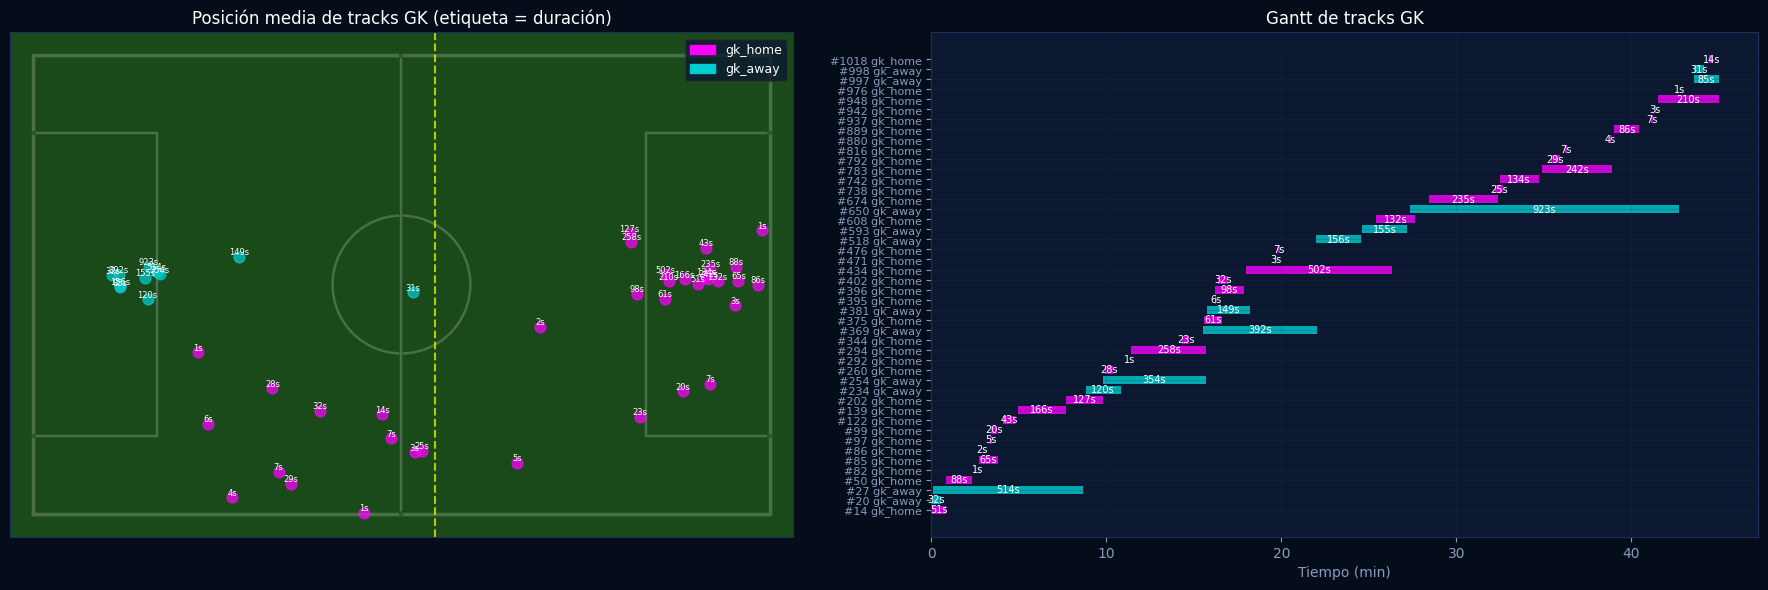

In [66]:
gk_tracks = track_info[track_info['cls'].isin(['gk_home','gk_away'])].copy()
print(f"Tracks portero total: {len(gk_tracks)}  (ideal: 2)")
print(f"  gk_home: {(gk_tracks['cls']=='gk_home').sum()}")
print(f"  gk_away: {(gk_tracks['cls']=='gk_away').sum()}")
print(f"  Duración media: {gk_tracks['duration_s'].mean():.1f}s  "
      f"mediana: {gk_tracks['duration_s'].median():.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)

# Posición media de cada track de portero
ax = axes[0]
draw_pitch(ax)
for _, r in gk_tracks.iterrows():
    color = COLOR[r['cls']]
    ax.scatter(r['mean_x'], r['mean_y'], s=60, color=color, alpha=0.7, zorder=5)
    ax.annotate(f"{r['duration_s']:.0f}s", (r['mean_x'], r['mean_y']),
                fontsize=6, color='white', ha='center', va='bottom', zorder=6)
ax.set_title('Posición media de tracks GK (etiqueta = duración)', color='white')
ph = mpatches.Patch(color=COLOR['gk_home'], label='gk_home')
pa = mpatches.Patch(color=COLOR['gk_away'], label='gk_away')
ax.legend(handles=[ph,pa], fontsize=9)

# Gantt de porteros
ax = axes[1]
ax.set_facecolor('#0c1830')
gk_sorted = gk_tracks.sort_values('f_start')
for i, (_, r) in enumerate(gk_sorted.iterrows()):
    t0 = (r['f_start'] - t_offset) / FPS / 60
    t1 = (r['f_end']   - t_offset) / FPS / 60
    ax.barh(i, t1-t0, left=t0, color=COLOR[r['cls']], alpha=0.8, height=0.8)
    ax.text(t0 + (t1-t0)/2, i, f"{r['duration_s']:.0f}s",
            ha='center', va='center', fontsize=7, color='white')
ax.set_yticks(range(len(gk_sorted)))
ax.set_yticklabels([f"#{r['gid']} {r['cls']}" for _, r in gk_sorted.iterrows()], fontsize=8)
ax.set_xlabel('Tiempo (min)')
ax.set_title('Gantt de tracks GK', color='white')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('diag_porteros.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 8  Simulación: ¿qué pasaría con skip_frames menor?

In [67]:
# Simulación del impacto de distintos skip_frames en la velocidad máxima detectable
# sin perder el track (asumiendo TRACK_MAX_DIST_M = 6m)
TRACK_MAX_DIST_M = 6.0
print(f"{'skip_f':>8} {'gap_ms':>8} {'gap_s':>7} {'max_vel km/h':>14} {'alcanza 6m?':>12}")
print('─'*55)
for sk in [1, 2, 3, 5, 8, 10, 15]:
    gap_s    = sk / FPS
    max_vel  = TRACK_MAX_DIST_M / gap_s * 3.6
    ok = 'SI ' if max_vel > 25 else 'FALLA '
    print(f"{sk:>8}   {gap_s*1000:>6.0f}ms   {gap_s:>5.3f}s   {max_vel:>12.1f}   {ok}")

print(f"\nCon skip={skip_eff} (actual): max vel trackeable = "
      f"{TRACK_MAX_DIST_M / (skip_eff/FPS) * 3.6:.1f} km/h")
print("(un jugador a 25km/h en sprint se mueve "
      f"{25/3.6 * skip_eff/FPS:.2f}m en {skip_eff} frames)")

  skip_f   gap_ms   gap_s   max_vel km/h  alcanza 6m?
───────────────────────────────────────────────────────
       1       33ms   0.033s          647.4   SI  ✓
       2       67ms   0.067s          323.7   SI  ✓
       3      100ms   0.100s          215.8   SI  ✓
       5      167ms   0.167s          129.5   SI  ✓
       8      267ms   0.267s           80.9   SI  ✓
      10      334ms   0.334s           64.7   SI  ✓
      15      501ms   0.501s           43.2   SI  ✓

Con skip=1 (actual): max vel trackeable = 647.4 km/h
(un jugador a 25km/h en sprint se mueve 0.23m en 1 frames)


## 9  Resumen diagnóstico automático

In [68]:
dur_min_val = df['t_min'].max()
n_ids       = track_info['gid'].nunique()
n_players   = 22 + 1  # 22 jugadores + árbitro
ratio       = n_ids / n_players
pct_short   = (track_info['duration_s'] < 2).mean() * 100
median_dur  = track_info['duration_s'].median()
seam_pct    = len(near_seam) / len(births_xy) * 100
reid_pct    = (len(df_matches) / total_tracks * 100) if total_tracks else 0
skip_max_vel = TRACK_MAX_DIST_M / (skip_eff/FPS) * 3.6

print("=" * 62)
print("  DIAGNÓSTICO DE FRAGMENTACIÓN")
print("=" * 62)
print(f"  Duración analizada : {dur_min_val:.1f} min")
print(f"  IDs únicos         : {n_ids}  (ideal ~{n_players})  → {ratio:.0f}x fragmentación")
print(f"  Duración mediana   : {median_dur:.1f}s por track")
print(f"  Tracks < 2s        : {pct_short:.0f}%")
print(f"  skip_frames efect. : {skip_eff}  → max vel trackeable {skip_max_vel:.0f} km/h")
print(f"  Tracks en seam ±10m: {seam_pct:.0f}%")
print(f"  Pares Re-ID recup. : {reid_pct:.0f}%")
print()
print("  DIAGNÓSTICO:")

issues = []
if skip_max_vel < 28:
    issues.append(f"[!] skip_frames={skip_eff} limita el tracker a {skip_max_vel:.0f} km/h "
                  f"→ BAJAR a 2-3")
if pct_short > 40:
    issues.append(f"[!] {pct_short:.0f}% de tracks duran <2s → "
                  f"el detector pierde jugadores frecuentemente")
if seam_pct > 30:
    issues.append(f"[!] {seam_pct:.0f}% de tracks nacen en zona de costura → "
                  f"duplicados generando IDs falsos")
if reid_pct > 20:
    issues.append(f"[!] {reid_pct:.0f}% de tracks son recuperables con Re-ID → "
                  f"ampliar TTL galería o relajar umbral")
if median_dur < 3:
    issues.append(f"[!] duración mediana {median_dur:.1f}s → "
                  f"posible TRACK_WINDOW_S demasiado corto")

if not issues:
    print("  Todo parece en rango.")
else:
    for iss in issues:
        print(f"  {iss}")

print()
print("  RECOMENDACIONES PRIORITARIAS:")
recs = []
if skip_max_vel < 28:
    recs.append((1, f"Bajar skip_frames de {skip_eff} a 2 o 3"))
if reid_pct > 20:
    recs.append((2, "Aumentar TTL galería Re-ID de 30s a 60-90s"))
if seam_pct > 30:
    recs.append((3, "Revisar parámetros de fusión bicámara (SEAM_MARGIN/FUSION)"))
if pct_short > 40:
    recs.append((4, "Bajar tau_p de 0.35 a 0.25-0.30 para más recall"))
recs.sort(key=lambda x: x[0])
for i, (_, r) in enumerate(recs, 1):
    print(f"  {i}. {r}")
print("=" * 62)

  DIAGNÓSTICO DE FRAGMENTACIÓN
  Duración analizada : 45.0 min
  IDs únicos         : 1002  (ideal ~23)  → 44x fragmentación
  Duración mediana   : 33.5s por track
  Tracks < 2s        : 7%
  skip_frames efect. : 1  → max vel trackeable 647 km/h
  Tracks en seam ±10m: 33%
  Pares Re-ID recup. : 43%

  DIAGNÓSTICO:
  [!] 33% de tracks nacen en zona de costura → duplicados generando IDs falsos
  [!] 43% de tracks son recuperables con Re-ID → ampliar TTL galería o relajar umbral

  RECOMENDACIONES PRIORITARIAS:
  1. Aumentar TTL galería Re-ID de 30s a 60-90s
  2. Revisar parámetros de fusión bicámara (SEAM_MARGIN/FUSION)


## 10  Simulación de mejoras — TTL Re-ID, costura y ByteTrack

Sweep TTL Re-ID (umbral distancia < 8m):
 TTL (s)  Pares recuperados  IDs resultantes  Reduccion %
      10                321              681         32.0
      30                435              567         43.4
      60                523              479         52.2
      90                565              437         56.4
     120                617              385         61.6
     180                694              308         69.3
     300                758              244         75.6

Ganancia 30s→90s  : +130.0 pares recuperados adicionales
Ganancia 30s→180s : +259.0 pares recuperados adicionales


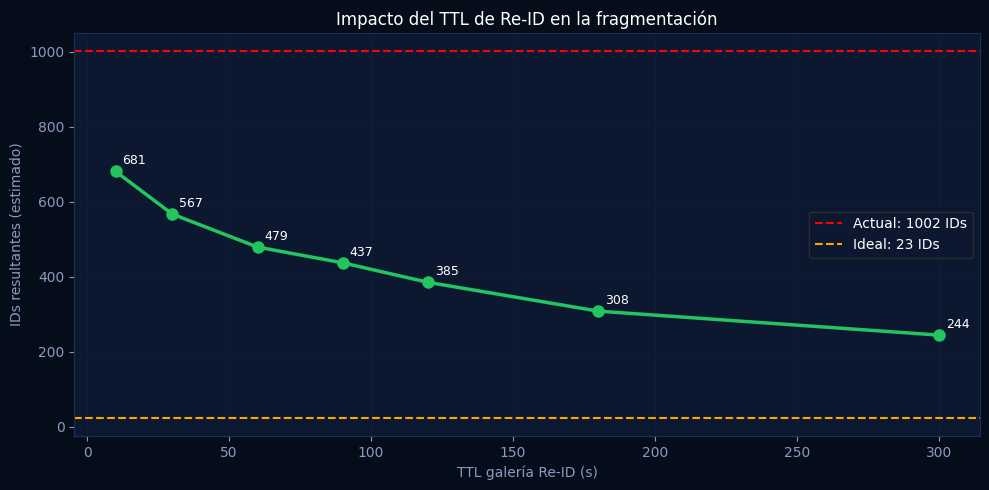

In [69]:
# ── A. SWEEP DE TTL DE RE-ID ─────────────────────────────────────────────────
# Para cada TTL, contamos cuántos pares muerto→nacido podrían conectarse
# con distancia < 8m. Esto mide el techo teórico de mejora Re-ID.
TTL_VALUES  = [10, 30, 60, 90, 120, 180, 300]
DIST_REID   = 8.0

ttl_results = []
for ttl_s in TTL_VALUES:
    ttl_f = int(ttl_s * FPS)
    recovered = 0
    for _, dead in deaths.iterrows():
        cands = births_xy[
            (births_xy['cls'] == dead['cls']) &
            (births_xy['f_start'] > dead['f_end']) &
            (births_xy['f_start'] <= dead['f_end'] + ttl_f) &
            (births_xy['gid'] != dead['gid'])
        ].dropna(subset=['birth_x','birth_y'])
        if not len(cands): continue
        cands = cands.copy()
        cands['dist'] = np.sqrt((cands['birth_x'] - dead['last_x'])**2 +
                                 (cands['birth_y'] - dead['last_y'])**2)
        if (cands['dist'] < DIST_REID).any():
            recovered += 1
    ttl_results.append({
        'TTL (s)': ttl_s,
        'Pares recuperados': recovered,
        'IDs resultantes': total_tracks - recovered,
        'Reduccion %': round(recovered / total_tracks * 100, 1)
    })

df_ttl = pd.DataFrame(ttl_results)
print("Sweep TTL Re-ID (umbral distancia < 8m):")
print(df_ttl.to_string(index=False))

# Ganancia incremental de ampliar TTL de 30 → 90s
r30  = df_ttl[df_ttl['TTL (s)'] == 30].iloc[0]['Pares recuperados']
r90  = df_ttl[df_ttl['TTL (s)'] == 90].iloc[0]['Pares recuperados']
r180 = df_ttl[df_ttl['TTL (s)'] == 180].iloc[0]['Pares recuperados']
print(f"\nGanancia 30s→90s  : +{r90 - r30} pares recuperados adicionales")
print(f"Ganancia 30s→180s : +{r180 - r30} pares recuperados adicionales")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor('#0c1830')
ax.plot(df_ttl['TTL (s)'], df_ttl['IDs resultantes'], 'o-', color='#22c55e', lw=2.5, ms=8)
ax.axhline(total_tracks, color='red',    lw=1.5, ls='--', label=f'Actual: {total_tracks} IDs')
ax.axhline(23,           color='orange', lw=1.5, ls='--', label='Ideal: 23 IDs')
for row in df_ttl.itertuples():
    ax.annotate(str(row._3), (row._1, row._3),
                textcoords='offset points', xytext=(5, 5), fontsize=9, color='white')
ax.set_xlabel('TTL galería Re-ID (s)'); ax.set_ylabel('IDs resultantes (estimado)')
ax.set_title('Impacto del TTL de Re-ID en la fragmentación', color='white', fontsize=12)
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('sim_ttl_reid.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [70]:
# ── B. PROXY BYTETRACK — oclusiones muy cortas (<10 frames, <3m) ─────────────
# ByteTrack mantiene vivo el track con predicción Kalman y recupera detecciones
# de baja confianza. Esto simula cuántos tracks se rompen en <10 frames que
# ByteTrack podría reconectar automáticamente.
BT_MAX_FRAMES = 10   # ~333ms buffer Kalman
BT_MAX_DIST   = 3.0  # metros: si el track predice bien, estará cerca

bt_matches = []
for _, dead in deaths.iterrows():
    cands = births_xy[
        (births_xy['cls'] == dead['cls']) &
        (births_xy['f_start'] > dead['f_end']) &
        (births_xy['f_start'] <= dead['f_end'] + BT_MAX_FRAMES) &
        (births_xy['gid'] != dead['gid'])
    ].dropna(subset=['birth_x','birth_y'])
    if not len(cands): continue
    cands = cands.copy()
    cands['dist'] = np.sqrt((cands['birth_x'] - dead['last_x'])**2 +
                             (cands['birth_y'] - dead['last_y'])**2)
    best = cands[cands['dist'] < BT_MAX_DIST].nsmallest(1, 'dist')
    if len(best):
        bt_matches.append({
            'gid_dead': dead['gid'], 'gid_born': best.iloc[0]['gid'],
            'cls': dead['cls'],
            'dist_m': best.iloc[0]['dist'],
            'gap_f': best.iloc[0]['f_start'] - dead['f_end']
        })

df_bt = pd.DataFrame(bt_matches)
print(f"ByteTrack proxy (gap < {BT_MAX_FRAMES} frames={BT_MAX_FRAMES/FPS*1000:.0f}ms, dist < {BT_MAX_DIST}m):")
print(f"  Tracks recuperables : {len(df_bt)} ({len(df_bt)/total_tracks*100:.1f}%)")
if len(df_bt):
    print(f"  Gap medio           : {df_bt['gap_f'].mean():.1f} frames ({df_bt['gap_f'].mean()/FPS*1000:.0f}ms)")
    print(f"  Distancia media     : {df_bt['dist_m'].mean():.2f}m")
    print()
    print("Por clase:")
    print(df_bt.groupby('cls').size().to_string())

# ── C. COSTURA — merges entre cámaras ────────────────────────────────────────
# Tracks que mueren cerca de la costura y otro nace cerca en <5s.
# Con más margen de distancia porque el jugador puede "saltar" en coordenadas.
SEAM_ZONE_M = 15.0
SEAM_GAP_S  = 5.0
SEAM_DIST_M = 12.0   # más tolerante porque hay error de proyección al cruzar

seam_gap_f = int(SEAM_GAP_S * FPS)
seam_deaths = deaths[
    (deaths['last_x'] > SEAM_X - SEAM_ZONE_M) &
    (deaths['last_x'] < SEAM_X + SEAM_ZONE_M)
]
seam_births_zone = births_xy[
    (births_xy['birth_x'] > SEAM_X - SEAM_ZONE_M) &
    (births_xy['birth_x'] < SEAM_X + SEAM_ZONE_M)
]

seam_matches = []
for _, dead in seam_deaths.iterrows():
    cands = seam_births_zone[
        (seam_births_zone['cls'] == dead['cls']) &
        (seam_births_zone['f_start'] > dead['f_end']) &
        (seam_births_zone['f_start'] <= dead['f_end'] + seam_gap_f) &
        (seam_births_zone['gid'] != dead['gid'])
    ].dropna(subset=['birth_x','birth_y'])
    if not len(cands): continue
    cands = cands.copy()
    cands['dist'] = np.sqrt((cands['birth_x'] - dead['last_x'])**2 +
                             (cands['birth_y'] - dead['last_y'])**2)
    best = cands[cands['dist'] < SEAM_DIST_M].nsmallest(1, 'dist')
    if len(best):
        seam_matches.append({
            'gid_dead': dead['gid'], 'gid_born': best.iloc[0]['gid'],
            'cls': dead['cls'],
            'dist_m': best.iloc[0]['dist'],
            'gap_s': (best.iloc[0]['f_start'] - dead['f_end']) / FPS
        })

df_seam = pd.DataFrame(seam_matches)
print(f"\nCostura (±{SEAM_ZONE_M}m de X={SEAM_X}m, gap<{SEAM_GAP_S}s, dist<{SEAM_DIST_M}m):")
print(f"  Merges posibles: {len(df_seam)} ({len(df_seam)/total_tracks*100:.1f}% del total)")
if len(df_seam):
    print(f"  Gap medio     : {df_seam['gap_s'].mean():.2f}s")
    print(f"  Distancia media: {df_seam['dist_m'].mean():.2f}m")

ByteTrack proxy (gap < 10 frames=334ms, dist < 3.0m):
  Tracks recuperables : 4 (0.4%)
  Gap medio           : 1.0 frames (33ms)
  Distancia media     : 2.01m

Por clase:
cls
player_away    2
referee        2

Costura (±15.0m de X=53.5m, gap<5.0s, dist<12.0m):
  Merges posibles: 131 (13.1% del total)
  Gap medio     : 2.32s
  Distancia media: 6.41m


  PROYECCION DE IDs CON CADA MEJORA
  Actual                              -> 1002 IDs  
  TTL Re-ID 90s                       -> 872.0 IDs  ###
  TTL Re-ID 180s                      -> 743.0 IDs  #######
  ByteTrack proxy                     ->  998 IDs  
  Costura fix                         ->  871 IDs  ###
  TTL 90s + Costura                   -> 744.0 IDs  #######
  TTL 180s + ByteTrack + Costura      -> 614.0 IDs  ###########
  Ideal (23 jugadores + arbitro)      ->   23 IDs

(Nota: cifras son techos teoricos. En la practica hay falsos positivos.)


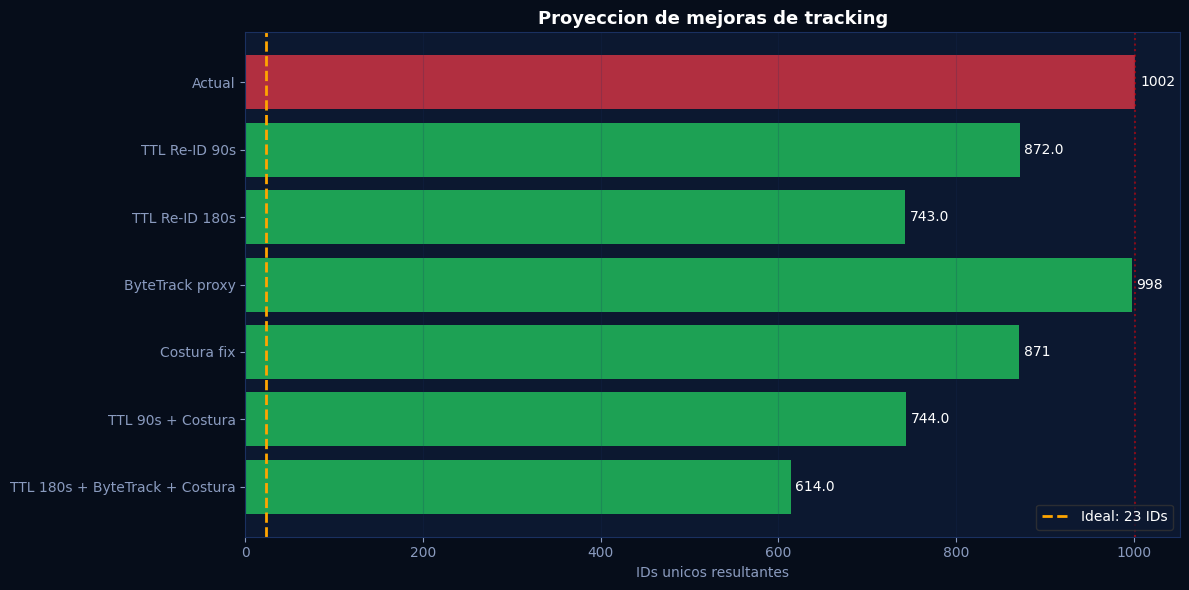

In [71]:
# ── D. RESUMEN COMPARATIVO — proyección de IDs con cada mejora ───────────────
bt_gain   = len(df_bt)
seam_gain = len(df_seam)
# Evitar doble conteo: ByteTrack y seam pueden solaparse
bt_only   = len(set(df_bt['gid_dead']) - set(df_seam['gid_dead'])) if len(df_seam) else bt_gain
seam_only = len(set(df_seam['gid_dead']) - set(df_bt['gid_dead'])) if len(df_bt) else seam_gain

scenarios = {
    'Actual':                         total_tracks,
    'TTL Re-ID 90s':                  total_tracks - (r90 - r30),
    'TTL Re-ID 180s':                 total_tracks - (r180 - r30),
    'ByteTrack proxy':                total_tracks - bt_gain,
    'Costura fix':                    total_tracks - seam_gain,
    'TTL 90s + Costura':              total_tracks - (r90 - r30) - seam_only,
    'TTL 180s + ByteTrack + Costura': total_tracks - (r180 - r30) - bt_only - seam_only,
}

print("=" * 60)
print("  PROYECCION DE IDs CON CADA MEJORA")
print("=" * 60)
for name, ids in scenarios.items():
    bar = '#' * max(0, int((total_tracks - ids) / total_tracks * 30))
    print(f"  {name:<35} -> {ids:>4} IDs  {bar}")
print(f"  {'Ideal (23 jugadores + arbitro)':<35} -> {'23':>4} IDs")
print("=" * 60)
print("\n(Nota: cifras son techos teoricos. En la practica hay falsos positivos.)")

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor('#0c1830')
labels = list(scenarios.keys())
values = list(scenarios.values())
colors = ['#dc3545' if v == total_tracks else '#22c55e' for v in values]
bars = ax.barh(labels, values, color=colors, alpha=0.8)
ax.axvline(23, color='orange', lw=2, ls='--', label='Ideal: 23 IDs')
ax.axvline(total_tracks, color='red', lw=1.5, ls=':', alpha=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, color='white')
ax.set_xlabel('IDs unicos resultantes')
ax.set_title('Proyeccion de mejoras de tracking', color='white', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.2, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('sim_mejoras.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2, os

# ── CSV options (sólo los que existen en disco) ────────────────────────────
_CSV_OPTS = {
    'StrongKalman — partido completo (45 min)':  'data/tracking_match.csv',
    'Muestra Banyoles f18000-18900':              'data/example_banyoles/tracking_sample.csv',
    'Muestra consolidada f18000-18900':           'data/example_banyoles/tracking_sample_consolidated.csv',
}
CSV_OPTIONS = {k: v for k, v in _CSV_OPTS.items() if os.path.exists(v)}
if not CSV_OPTIONS:
    raise FileNotFoundError("No se encontró ningún CSV de tracking.")

VIDEO_PATHS = {'left': 'left.mp4', 'right': 'right.mp4'}

# ── Lazy caches ────────────────────────────────────────────────────────────
_csv_cache = {}   # label → (df_by_frame, frame_list, T_MIN_ARR)
_cap_cache = {}   # side  → cv2.VideoCapture | None

def _load_csv(label):
    if label in _csv_cache:
        return _csv_cache[label]
    path = CSV_OPTIONS[label]
    print(f"Cargando {path}...", end=' ', flush=True)
    df_raw = pd.read_csv(path)
    if 'track_id' in df_raw.columns and 'gid' not in df_raw.columns:
        df_raw = df_raw.rename(columns={'track_id': 'gid', 'class': 'cls',
                                         'x': 'x_m', 'y': 'y_m'})
    df_raw = df_raw.sort_values(['gid', 'frame'])
    dbf = {fr: grp[['gid', 'cls', 'x_m', 'y_m']].reset_index(drop=True)
           for fr, grp in df_raw.groupby('frame')}
    fl  = sorted(dbf.keys())
    tma = [(f - fl[0]) / FPS / 60 for f in fl]
    _csv_cache[label] = (dbf, fl, tma)
    print(f"listo. {len(fl)} frames.")
    return _csv_cache[label]

def _get_cap(side):
    if side not in _cap_cache:
        path = VIDEO_PATHS[side]
        _cap_cache[side] = cv2.VideoCapture(path) if os.path.exists(path) else None
    return _cap_cache[side]

def _read_video_frame(side, frame_num):
    cap = _get_cap(side)
    if cap is None:
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_num))
    ret, frame = cap.read()
    if not ret:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# ── Pre-carga del CSV por defecto ──────────────────────────────────────────
_first_label = list(CSV_OPTIONS.keys())[0]
_dbf0, _fl0, _tma0 = _load_csv(_first_label)

# ── Función de dibujo ──────────────────────────────────────────────────────
out_v = widgets.Output()

def _draw_frame(label, frame_i, trail_s=1.0, show_video=True):
    dbf, fl, tma = _load_csv(label)
    frame_i = int(np.clip(frame_i, 0, len(fl) - 1))
    frame   = fl[frame_i]
    rows    = dbf.get(frame, pd.DataFrame())
    t_min   = tma[frame_i]

    has_video = show_video and (os.path.exists('left.mp4') or os.path.exists('right.mp4'))

    if has_video:
        fig = plt.figure(figsize=(20, 14))
        gs  = gridspec.GridSpec(2, 2, height_ratios=[1, 1.5], hspace=0.06, wspace=0.03)
        ax_L  = fig.add_subplot(gs[0, 0])
        ax_R  = fig.add_subplot(gs[0, 1])
        ax_fd = fig.add_subplot(gs[1, :])
    else:
        fig, ax_fd = plt.subplots(figsize=(18, 11))
    fig.patch.set_facecolor(DARK_BG)

    # ── Vídeo ──────────────────────────────────────────────────────────────
    if has_video:
        for ax_v, side in [(ax_L, 'left'), (ax_R, 'right')]:
            img = _read_video_frame(side, frame)
            ax_v.set_facecolor('#050505')
            if img is not None:
                ax_v.imshow(img, aspect='auto')
                ax_v.set_title(f'{side}.mp4  frame {frame}', color='#aaa', fontsize=9, pad=3)
            else:
                ax_v.text(0.5, 0.5, f'{side}.mp4\nno disponible',
                          transform=ax_v.transAxes, ha='center', va='center',
                          color='#666', fontsize=11)
            ax_v.axis('off')

    # ── Campo ──────────────────────────────────────────────────────────────
    draw_pitch(ax_fd)
    ax_fd.set_title(
        f'Frame {frame}   t = {t_min:.2f} min   IDs activos: {len(rows)}   [{label}]',
        color='white', fontsize=11, fontweight='bold')

    trail_f = int(trail_s * FPS)
    if trail_f > 0:
        for j in range(max(0, frame_i - trail_f), frame_i):
            prev = dbf.get(fl[j], pd.DataFrame())
            if prev.empty:
                continue
            alpha = 0.08 + 0.35 * (j - (frame_i - trail_f)) / max(trail_f, 1)
            ax_fd.scatter(prev['x_m'], prev['y_m'], s=8,
                          c=[COLOR.get(c, '#888') for c in prev['cls']],
                          alpha=alpha, zorder=3)

    if not rows.empty:
        ax_fd.scatter(rows['x_m'], rows['y_m'], s=90, zorder=5,
                      c=[COLOR.get(c, '#888') for c in rows['cls']],
                      edgecolors='white', linewidths=0.6, alpha=0.95)
        for _, r in rows.iterrows():
            ax_fd.annotate(str(int(r['gid'])), (r['x_m'], r['y_m']),
                           fontsize=6.5, color='white', ha='center', va='bottom',
                           fontweight='bold', zorder=6)

    handles = [mpatches.Patch(color=COLOR[c], label=c)
               for c in ['player_home', 'player_away', 'gk_home', 'gk_away', 'referee', 'unknown']]
    ax_fd.legend(handles=handles, fontsize=8, loc='lower right')
    plt.tight_layout()
    with out_v:
        clear_output(wait=True)
        plt.show()
    plt.close()

# ── Widgets ────────────────────────────────────────────────────────────────
dd_csv = widgets.Dropdown(
    options=list(CSV_OPTIONS.keys()), value=_first_label,
    description='CSV:', layout=widgets.Layout(width='60%'),
    style={'description_width': '40px'})

chk_video = widgets.Checkbox(
    value=os.path.exists('left.mp4'), description='Mostrar vídeo',
    indent=False, layout=widgets.Layout(width='155px'))

slider_f = widgets.IntSlider(
    min=0, max=len(_fl0)-1, value=0, step=1, description='Frame',
    layout=widgets.Layout(width='75%'), style={'description_width': '55px'})
slider_t = widgets.FloatSlider(
    min=0, max=5, value=1, step=0.5, description='Trail (s)',
    layout=widgets.Layout(width='48%'), style={'description_width': '70px'})
lbl_time = widgets.Label(value='t = 0.00 min', layout=widgets.Layout(width='115px'))

btn_m30 = widgets.Button(description='-30s', layout=widgets.Layout(width='62px'), button_style='info')
btn_m5  = widgets.Button(description='-5s',  layout=widgets.Layout(width='55px'), button_style='info')
btn_p5  = widgets.Button(description='+5s',  layout=widgets.Layout(width='55px'), button_style='success')
btn_p30 = widgets.Button(description='+30s', layout=widgets.Layout(width='62px'), button_style='success')

def _redraw(*_):
    _, fl, tma = _load_csv(dd_csv.value)
    idx = int(np.clip(slider_f.value, 0, len(fl) - 1))
    lbl_time.value = f't = {tma[idx]:.2f} min'
    _draw_frame(dd_csv.value, idx, slider_t.value, chk_video.value)

def _on_csv_change(change):
    _, fl, _ = _load_csv(change['new'])
    slider_f.unobserve(_redraw, names='value')
    slider_f.max = len(fl) - 1
    slider_f.value = 0
    slider_f.observe(_redraw, names='value')
    _redraw()

def _jump(ds):
    _, fl, _ = _load_csv(dd_csv.value)
    slider_f.value = int(np.clip(slider_f.value + ds * FPS, 0, len(fl) - 1))

btn_m30.on_click(lambda _: _jump(-30))
btn_m5.on_click(lambda _:  _jump(-5))
btn_p5.on_click(lambda _:  _jump(5))
btn_p30.on_click(lambda _: _jump(30))

dd_csv.observe(_on_csv_change, names='value')
slider_f.observe(_redraw, names='value')
slider_t.observe(_redraw, names='value')
chk_video.observe(_redraw, names='value')

ui = widgets.VBox([
    widgets.HBox([dd_csv, chk_video]),
    widgets.HBox([btn_m30, btn_m5, slider_f, btn_p5, btn_p30, lbl_time]),
    slider_t,
])
display(ui, out_v)
_draw_frame(_first_label, 0, 1.0, chk_video.value)

## 11  Visor interactivo de frames